# Dask DataFrame (1)

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Dask DataFrame"
* https://docs.dask.org/en/latest/dataframe.html
* Jesse C. Daniel. Data Science with Python and Dask.

* https://docs.dask.org/en/stable/generated/dask.dataframe.DataFrame.memory_usage_per_partition.html#dask.dataframe.DataFrame.memory_usage_per_partition
* https://docs.dask.org/en/stable/generated/dask.dataframe.DataFrame.map_partitions.html#dask.dataframe.DataFrame.map_partitions
* https://docs.dask.org/en/stable/generated/dask.array.histogram.html
* https://docs.dask.org/en/stable/dataframe-categoricals.html
* https://docs.dask.org/en/stable/generated/dask.dataframe.DataFrame.pivot_table.html#dask.dataframe.DataFrame.pivot_table

* https://docs.dask.org/en/stable/best-practices.html
* https://docs.dask.org/en/stable/dashboard.html
* https://distributed.dask.org/en/stable/client.html

## Задачи для совместного разбора

1\. Создать `dask.DataFrame`. Рассмотреть основные возможности (выбор строк, работа с датами, добавление столбцов)

In [ ]:
import dask
import dask.dataframe as dd

In [ ]:
df = dask.datasets.timeseries(start="2023-01-01", end="2023-04-24")
df.tail()

,name,id,x,y
timestamp,,,,
2023-04-23 23:59:55,Laura,968,0.895884,-0.372601
2023-04-23 23:59:56,Zelda,971,0.209201,0.899211
2023-04-23 23:59:57,George,1001,0.786169,-0.509877
2023-04-23 23:59:58,Xavier,1081,0.618649,-0.613346
2023-04-23 23:59:59,Bob,1052,0.986316,0.804464


In [ ]:
df.dtypes

name     object
id        int64
x       float64
y       float64
dtype: object

In [ ]:
tims = df["name"] == "Tim"
df[tims].head(5)

,name,id,x,y
timestamp,,,,
2023-01-01 00:00:16,Tim,998,-0.717562,0.186138
2023-01-01 00:00:21,Tim,1062,0.569370,-0.410180
2023-01-01 00:00:56,Tim,1026,0.610211,-0.205652
2023-01-01 00:01:19,Tim,1073,-0.612368,-0.517130
2023-01-01 00:01:29,Tim,1044,0.678750,0.432034


In [ ]:
df.query("name == 'Tim'").head(2)

,name,id,x,y
timestamp,,,,
2023-01-01 00:00:16,Tim,998,-0.717562,0.186138
2023-01-01 00:00:21,Tim,1062,0.569370,-0.410180


In [ ]:
df.index.dt.year.head()

Int64Index([2023, 2023, 2023, 2023, 2023], dtype='int64', name='timestamp')

In [ ]:
df["name"].str.lower().head()

timestamp
2023-01-01 00:00:00    charlie
2023-01-01 00:00:01      quinn
2023-01-01 00:00:02     ursula
2023-01-01 00:00:03    charlie
2023-01-01 00:00:04      kevin
Freq: S, Name: name, dtype: object

In [ ]:
df["key"] = df["name"].map(lambda n: n[0])
df.head()

,name,id,x,y,key
timestamp,,,,,
2023-01-01 00:00:00,Charlie,1006,0.444880,-0.334337,C
2023-01-01 00:00:01,Quinn,981,-0.459665,-0.778739,Q
2023-01-01 00:00:02,Ursula,975,-0.412212,-0.369206,U
2023-01-01 00:00:03,Charlie,961,0.466911,0.262071,C
2023-01-01 00:00:04,Kevin,964,0.371640,-0.366557,K


2\. Используя метод pipe, добавьте столбец с полом человека и нормализуйте столбцы x и y

In [ ]:
df[...] = ...
...
df[...] = ...
df[...] = ...
df[...] = ...
df[...] = ...

In [ ]:
df["name"].unique().compute()

0      Charlie
1        Quinn
2       Ursula
3        Kevin
4        Sarah
5        Alice
6        Zelda
7      Norbert
8       Oliver
9        Frank
10         Tim
11      Ingrid
12       Jerry
13       Laura
14      Yvonne
15         Bob
16      Victor
17         Ray
18      Xavier
19       Wendy
20      George
21     Michael
22         Dan
23      Hannah
24       Edith
25    Patricia
Name: name, dtype: object

In [ ]:
def add_gender(df):
    male_names = {"Charlie", "Dan", "George", "Victor"}
    df["gender"] = "f"
    df["gender"] = df["gender"].mask(df["name"].isin(male_names), "m")
    return df

def normalize_column(df, colname):
    df[colname] = df[colname] / df[colname].max()
    return df

def add_key(df):
    df["key"] = df["name"].map(lambda n: n[0])
    return df

In [ ]:
# df = dask.datasets.timeseries(start="2023-01-01", end="2023-04-24")
df_t = (df
#  .pipe(lambda df: df.copy())
 .pipe(add_key)
 .pipe(add_gender)
 .pipe(normalize_column, colname="x")
 .pipe(normalize_column, colname="y")
)
df_t.head()

,name,id,x,y,key,gender
timestamp,,,,,,
2023-01-01 00:00:00,Xavier,1032,-0.472616,-0.721367,X,f
2023-01-01 00:00:01,Hannah,1016,-0.966701,-0.536291,H,f
2023-01-01 00:00:02,Ingrid,1017,-0.805353,0.317677,I,f
2023-01-01 00:00:03,Norbert,1032,-0.801569,-0.285791,N,f
2023-01-01 00:00:04,Patricia,1083,-0.045081,-0.976568,P,f


3\. При помощи сводных таблиц посчитайте для каждой пары (gender, key) среднее значение по столбцу x.

In [ ]:
df_t.pivot_table(
    index="key",
    columns="gender",
    values="x",
    aggfunc="mean"
)

ValueError: 'columns' must be category dtype

In [ ]:
# df_t["gender_cat"] = df_t["gender"].astype("category").cat.as_known()
df_t["gender_cat"] = df_t["gender"].astype("category").cat.set_categories(
    ["m", "f"]
)
df_t

,name,id,x,y,key,gender,gender_cat
npartitions=113,,,,,,,
2023-01-01,object,int32,float64,float64,object,object,category[known]
2023-01-02,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...
2023-04-23,...,...,...,...,...,...,...
2023-04-24,...,...,...,...,...,...,...


In [ ]:
df_t.pivot_table(
    index="key",
    columns="gender_cat",
    values="x",
    aggfunc="mean"
).compute()

gender_cat,m,f
key,,
A,NaN,0.000600
B,NaN,-0.000763
C,0.000319,NaN
D,-0.001641,NaN
E,NaN,-0.001344
F,NaN,0.001296
G,0.001714,NaN
H,NaN,0.000325
I,NaN,0.000149


## Лабораторная работа 12

__При решении данных задач не подразумевается использования циклов или генераторов Python в ходе работы с пакетами `numpy`, `pandas` и `dask`, если в задании не сказано обратного. Решения задач, в которых для обработки массивов `numpy`, структур `pandas` или структур `dask` используются явные циклы (без согласования с преподавателем), могут быть признаны некорректными и не засчитаны.__

В ходе выполнения все операции вычислений проводятся над `dask.DataFrame` и средствами пакета `dask`, если в задании не сказано обратного. Переход от `dask.DataFrame` к `pd.DataFrame` возможен исключительно для демонстрации результата в конце решения задачи. Если в задаче используются результаты выполнения предыдущих задач, то подразумевается, что вы используете результаты в виде `dask.DataFrame` (то есть то, что было получено до вызова `compute`, а не после).

<p class="task" id="1"></p>

1\. В архиве `recipes_full.zip` находятся файлы, содержащие информацию об рецептах блюд. Загрузите данные из файлов этого архива в виде `dd.DataFrame` с названием `recipes`. Укажите, что в столбце `submitted` содержатся даты. Выведите на экран информацию о количестве сегментов и типе столбцов. Выведите на экран 5 первых и 5 последних строк таблицы. В случае сообщения об ошибке объясните причину и исправьте ошибку.

In [ ]:
recipes = dd.read_csv('/Users/ivanlopatkin/Downloads/recipes_full/recipes_full_*.csv', dtype={'minutes': 'float64',
                                                                                              'n_steps': 'float64'})

In [ ]:
recipes.submitted = dd.to_datetime(recipes.submitted)

In [ ]:
recipes.npartitions

8

In [ ]:
recipes.dtypes

id                         int64
name                      object
minutes                  float64
contributor_id             int64
submitted         datetime64[ns]
n_steps                  float64
description               object
n_ingredients              int64
dtype: object

In [ ]:
recipes.head()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,683970,vant ivoire mickies nothing,33.0,803776,2019-08-22,4.0,pat and gina neely and their family own and op...,9
1,1089012,kremsils mariposa baccala cookies class borage...,23.0,51579,2013-03-02,1.0,"a light, tasty and easy to put together chicke...",5
2,1428572,tania lander,0.0,68884,1980-11-09,1.0,a delicious melt in your mouth appetizer. for ...,5
3,1400250,heloise milli asher doogh zojirushi,24.0,678862,2018-04-29,3.0,delicious cream cheese and peach filled cresce...,1
4,387709,nutty chocolate chunk cookies,47.0,489552,2009-08-31,8.0,everyone loves these buttery cookies chock ful...,10


In [ ]:
recipes.tail()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
278949,1029131,tuti waffle snackies steakhouse,19.0,171345,1973-10-18,4.0,"according to a providence journal article, ama...",4
278950,1700703,noelias cheats crocante fleisch zitumbuwa,1.0,30228,2007-07-01,6.0,if possible sauté the onions and garlic in abo...,1
278951,1910650,rubbed restuffed pelmeni bedouin flavourful,60.0,591905,2009-09-26,3.0,another great recipe to add to the growing swe...,2
278952,713836,stems polpettine peezi,NaN,357389,2003-09-30,4.0,adapted from top secret recipes. love this!,9
278953,660699,clementines,64.0,29196,1973-06-03,6.0,this would make a great start to your holiday ...,8


**ValueError: Mismatched dtypes found in `pd.read_csv`/`pd.read_table`**

> В разных партишенах в колонках minutes и n_steps типы данных различны, чтобы пофиксить ошибку, достаточно привести их к одному типу данных

Предлагаемое решение:
dtype={'minutes': 'float64',
       'n_steps': 'float64'}

<p class="task" id="2"></p>

2\. Выведите на экран следующую информацию:
* количество сегментов в таблице
* объем используемой памяти каждого сегмента
* количество строк в каждом сегменте
* количество строк во всей таблице.

In [ ]:
recipes.npartitions

8

In [ ]:
recipes.map_partitions(lambda x: sum(x.memory_usage())).compute()

0    17853248
1    17853248
2    17853248
3    17853248
4    17853248
5    17853184
6    17853184
7    17853184
dtype: int64

In [ ]:
recipes.map_partitions(lambda x: len(x)).compute()

0    278955
1    278955
2    278955
3    278955
4    278955
5    278954
6    278954
7    278954
dtype: int64

In [ ]:
recipes.compute().shape[0]

2231637

In [ ]:
type(recipes.compute())

pandas.core.frame.DataFrame

In [ ]:
len(recipes)

2231637

<p class="task" id="3"></p>

3\. Воспользовавшись индексатором `loc`, отберите строки фрейма `recipes`, имеющие индекс 42. Выведите полученные строки и их количество на экран. Объясните результат в виде текстового комментария.

In [ ]:
recipes.index.unique().compute()[:60]

Int64Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
            17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
            34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
            51, 52, 53, 54, 55, 56, 57, 58, 59],
           dtype='int64')

In [ ]:
ind_42 = recipes.loc[42, :]
ind_42.compute()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients
42,223847,gyros burgers,25.0,451301,2007-04-21,5.0,this is a greek/american lamb and beef mixture...,11
42,1218643,zazu thisclose portage dahi,39.0,68357,1993-04-13,5.0,recipe is from fleischmann's breadworld.com. ...,6
42,265832,alber ensalada,35.0,1155210,1976-02-17,3.0,"this is a recipe i developed years back, it's ...",7
42,1972307,eclectic rigamarta bechamel bananarita chipiro...,30.0,82616,1996-11-29,1.0,its a a tradition in our family to have an ear...,8
42,1116892,reid pot meatza roseland trouble gougere tunes...,18.0,1389351,2003-07-24,3.0,this is a great dish for brunches. you can us...,8
42,249625,african peanut and ginger chicken,120.0,317934,2007-08-29,17.0,add precooked chicken to soup-like mixture and...,13
42,452814,pepper jack mac,45.0,174096,2011-04-03,7.0,a spicy twist on mac & cheese - delicious! i ...,7
42,1601792,fetasaganaki kalaloo kabos unbaked jhal decision,57.0,27678,1990-07-08,3.0,yummy and spicy pumpkin fudge,6


In [ ]:
len(ind_42)

8

**Все 8 партов имеют одну и ту же структуру индексов, поэтому во всех партишенах есть индекс 42**

<p class="task" id="4"></p>

4\. Выясните, сколько рецептов содержат слово `chocolate` в названии (`name`). Выведите на количество уникальных идентификаторов авторов таких рецептов.

In [ ]:
mask = recipes.name.str.contains('chocolate')
mask.unique().compute()

0    False
1     True
2      NaN
Name: name, dtype: object

In [ ]:
recipes.compute().shape

(2231637, 8)

In [ ]:
recipes.name.dropna().compute().shape

(2231625,)

In [ ]:
clear_names = recipes.name.dropna()

In [ ]:
import dask.array as da
import warnings
warnings.filterwarnings('ignore')

In [ ]:
mask = clear_names.str.contains('chocolate')
len(clear_names[mask])

11628

In [ ]:
recipes.name = recipes.name.fillna('')

In [ ]:
with_chocolate = recipes[recipes.name.str.contains('chocolate')]

In [ ]:
with_chocolate.contributor_id.nunique().compute()

4457

<p class="task" id="5"></p>

5\. При помощи функции `da.histogram` посчитайте значения для построения гистограммы для столбца `n_ingredients`. Визуализируйте полученные результаты при помощи функции `plt.bar`. Добавьте на рисунок 2 вертикальные линии, соответствующие квантилям уровней 0.25 и 0.75. Сделайте масштаб вертикальной оси логарифмическим.

Допускается вычисление статистики по столбцу (применение метода `compute`) до того, как будет вызван `da.histogram`.

In [ ]:
import matplotlib.pyplot as pl
import numpy as np

In [ ]:
recipes.n_ingredients.describe().compute()

count    2.231637e+06
mean     5.419801e+00
std      2.990839e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      8.000000e+00
max      4.300000e+01
Name: n_ingredients, dtype: float64

In [ ]:
recipes.n_ingredients.nunique().compute()

41

In [ ]:
hist, bins = da.histogram(recipes.n_ingredients, bins=50, range=(0, 46))

In [ ]:
bins, hist.compute()

(array([ 0.  ,  0.92,  1.84,  2.76,  3.68,  4.6 ,  5.52,  6.44,  7.36,
         8.28,  9.2 , 10.12, 11.04, 11.96, 12.88, 13.8 , 14.72, 15.64,
        16.56, 17.48, 18.4 , 19.32, 20.24, 21.16, 22.08, 23.  , 23.92,
        24.84, 25.76, 26.68, 27.6 , 28.52, 29.44, 30.36, 31.28, 32.2 ,
        33.12, 34.04, 34.96, 35.88, 36.8 , 37.72, 38.64, 39.56, 40.48,
        41.4 , 42.32, 43.24, 44.16, 45.08, 46.  ]),
 array([     0, 222071, 224158, 229388, 234948, 240720, 244360, 247181,
        246747, 246816,  22430,  19094,      0,  15165,  11640,   8284,
          6014,   4145,   2793,   1913,   1279,    852,    529,    346,
             0,    244,    178,    107,     68,     55,     33,     22,
            20,     13,      5,      4,      3,      0,      4,      1,
             2,      1,      1,      2,      0,      0,      1,      0,
             0,      0]))

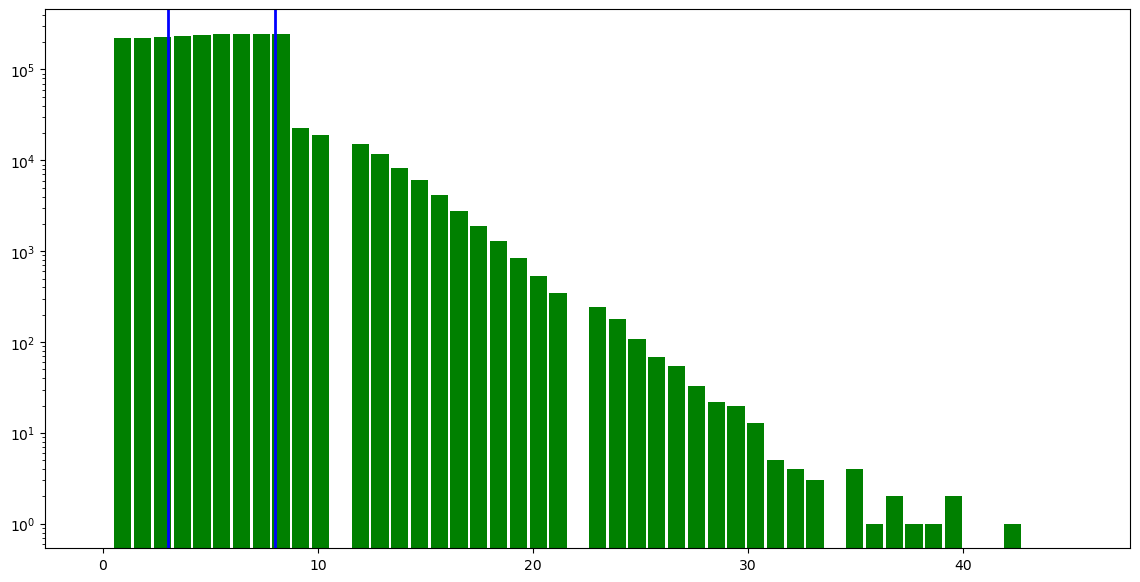

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_yscale('log')
ax.bar(bins[:-1], hist.compute(), color='green')
q25, q75 = np.percentile(recipes.n_ingredients, [25, 75])
ax.axvline(q25, color='blue', linewidth=2)
ax.axvline(q75, color='blue', linewidth=2)

plt.show()

<p class="task" id="6"></p>

6\. Напишите функции:
* `minutes_to_hours(df)`, которая принимает на вход фрейм и заменяет столбец `minutes` на столбец `hours` с соответствующим преобразованием чисел;
* `extract_ymd(df)`, которая добавляет 3 столбца: `year`, `month` и `day`, полученные на основе столбца `submitted`;
* `add_month_name(df)`, которая добавляет категориальный столбец `month_name` с названием месяца из даты и вызывает для него метод `.cat.as_known()`.

Создайте фрейм `recipes_pipe` путем цепочки вызовов метода `pipe` с применением данных функций. Выведите на экран строку, соответствующую рецепту с id=683970. Для отбора строки воспользуйтесь методом `query`.

In [ ]:
def minutes_to_hours(df):
    df.minutes = df.minutes / 60
    df = df.rename(columns={'minutes': 'hours'})
    return df

def extract_ymd(df):
    df['year'] = df.submitted.dt.year
    df['month'] = df.submitted.dt.month
    df['day'] = df.submitted.dt.day
    return df

def add_month_name(df):
    df['month_name'] = df.submitted.dt.month_name().astype("category").cat.as_known()
    return df

In [ ]:
recipes_copy = recipes.copy()

In [ ]:
recipes_pipe = (recipes_copy
                .pipe(minutes_to_hours)
                .pipe(extract_ymd)
                .pipe(add_month_name))

In [ ]:
recipes_pipe.head()

,id,name,hours,contributor_id,submitted,n_steps,description,n_ingredients,year,month,day,month_name
0,683970,vant ivoire mickies nothing,0.550000,803776,2019-08-22,4.0,pat and gina neely and their family own and op...,9,2019,8,22,August
1,1089012,kremsils mariposa baccala cookies class borage...,0.383333,51579,2013-03-02,1.0,"a light, tasty and easy to put together chicke...",5,2013,3,2,March
2,1428572,tania lander,0.000000,68884,1980-11-09,1.0,a delicious melt in your mouth appetizer. for ...,5,1980,11,9,November
3,1400250,heloise milli asher doogh zojirushi,0.400000,678862,2018-04-29,3.0,delicious cream cheese and peach filled cresce...,1,2018,4,29,April
4,387709,nutty chocolate chunk cookies,0.783333,489552,2009-08-31,8.0,everyone loves these buttery cookies chock ful...,10,2009,8,31,August


In [ ]:
recipes_pipe.query('id == 683970').compute()

,id,name,hours,contributor_id,submitted,n_steps,description,n_ingredients,year,month,day,month_name
0,683970,vant ivoire mickies nothing,0.55,803776,2019-08-22,4.0,pat and gina neely and their family own and op...,9,2019,8,22,August


<p class="task" id="7"></p>

7\. Используя результат предыдущей задачи, постройте сводную таблицу при помощи метода `pivot_table`, где по строкам располагаются года, по столбцам - названия месяцев, а в ячейках содержится средняя длина рецептов (в часах) в данный год и месяц. Выведите таблицу на экран. Выведите на экран информацию за апрель 1970-1975 годов (включительно).

In [ ]:
pivot = recipes_pipe.pivot_table(
    index="year",
    columns="month_name",
    values="hours",
    aggfunc="mean"
)

In [ ]:
pivot.compute()

month_name,April,August,December,February,January,July,June,March,May,November,October,September
year,,,,,,,,,,,,
1970,0.535253,0.544904,0.535515,0.531530,0.532693,0.542781,0.544243,0.528301,0.536688,0.537969,0.532659,0.538930
1971,0.547731,0.530590,0.543796,0.533528,0.533237,0.545502,0.536644,0.535626,0.529507,0.531603,0.542461,0.545521
1972,0.531383,0.543788,0.540724,0.527673,0.527548,0.539933,0.530001,0.543361,0.539681,0.545566,0.536516,0.542677
1973,0.533646,0.546603,0.542902,0.538645,0.539917,0.530634,0.535194,0.533162,0.534956,0.538673,0.535226,0.528227
1974,0.540382,0.528316,0.535279,0.539811,0.535436,0.542733,0.532864,0.540594,0.542213,0.537463,0.536957,0.536616
1975,0.535514,0.534260,0.534445,0.533850,0.543938,0.538529,0.534805,0.539711,0.530531,0.541481,0.529238,0.548624
1976,0.543596,0.536620,0.532532,0.534188,0.548785,0.540760,0.528133,0.538327,0.537886,0.532967,0.540424,0.542933
1977,0.534943,0.536607,0.541353,0.537868,0.531178,0.542600,0.538966,0.532360,0.533895,0.536143,0.529759,0.531099
1978,0.536417,0.540905,0.540035,0.533373,0.538842,0.539100,0.539322,0.529556,0.537688,0.534920,0.545526,0.545815


In [ ]:
pivot.loc[1970:1975, ['April']].compute()

month_name,April
year,
1970,0.535253
1971,0.547731
1972,0.531383
1973,0.533646
1974,0.540382
1975,0.535514


<p class="task" id="8"></p>

8\. В архиве `recipes_additional.zip` находятся файлы, содержащие информацию об рецептах блюд, полученные из другого источника. В связи с этим названия и количество столбцов в этих данных отличаются от того, что находится в архиве `recipes_full.zip`.

Объедините два набора набора данных (добавьте строки из одного набора данных к другому), согласовав названия столбцов и форматы данных. Итоговый фрейм должен содержать следующие колонки: `id`, `name`, `minutes`, `contributor_id`, `submitted`, `n_steps`, `description`, `n_ingredients`, `#tags` и `view_30_days`. Добавьте столбец `dset` с информацией о том, из какого датасета была получены данные.

Выведите на экран количество пропусков в каждом из столбцов полученной таблицы и общее количество строк в ней.

In [ ]:
recipes_2 = dd.read_csv('/Users/ivanlopatkin/Downloads/recipes_additional/recipes_additional_*.csv')

In [ ]:
recipes_2.npartitions

5

In [ ]:
recipes_2['minutes'] = recipes_2['hours'] * 60
recipes_2['id'] = recipes_2['recipe_id']
recipes_2['submitted'] = recipes_2['date_of_publication']
recipes_2['n_ingredients'] = recipes_2['#ingredients']
recipes_2.head()

In [ ]:
recipes['dset'], recipes_2['dset'] = 'start_recipes', 'add_recipes'

In [ ]:
merged = (dd.multi.concat([recipes, recipes_2])).drop(['hours', 'date_of_publication', '#ingredients', 'recipe_id'], axis=1)
merged.compute()

,id,name,minutes,contributor_id,submitted,n_steps,description,n_ingredients,dset,#tags,views_30_days
0,683970,vant ivoire mickies nothing,33.0,803776.0,2019-08-22 00:00:00,4.0,pat and gina neely and their family own and op...,9,start_recipes,NaN,NaN
1,1089012,kremsils mariposa baccala cookies class borage...,23.0,51579.0,2013-03-02 00:00:00,1.0,"a light, tasty and easy to put together chicke...",5,start_recipes,NaN,NaN
2,1428572,tania lander,0.0,68884.0,1980-11-09 00:00:00,1.0,a delicious melt in your mouth appetizer. for ...,5,start_recipes,NaN,NaN
3,1400250,heloise milli asher doogh zojirushi,24.0,678862.0,2018-04-29 00:00:00,3.0,delicious cream cheese and peach filled cresce...,1,start_recipes,NaN,NaN
4,387709,nutty chocolate chunk cookies,47.0,489552.0,2009-08-31 00:00:00,8.0,everyone loves these buttery cookies chock ful...,10,start_recipes,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
325814,20eadf,plas hachis,35.0,NaN,29/06/1997,NaN,"if you like the sound of this, you are gonna l...",1,add_recipes,5.0,667.0
325815,14d0d8,stephen jackpot guatemalan bredie cocoatana ma...,42.0,NaN,16/09/1981,NaN,a cool and creamy dessert!,9,add_recipes,10.0,2269.0
325816,1c0728,derves camp schmere krbissuppe fldekager,15.0,NaN,22/01/1999,NaN,quick and easy. tasty alternative to tradition...,4,add_recipes,5.0,681.0
325817,eb528,texans zuring mumble limas bouclair besan duvall,59.0,NaN,07/02/1973,NaN,5-ingredient fix contest entry. tasty little ...,5,add_recipes,9.0,3683.0


In [ ]:
merged.isna().sum().compute()

id                      0
name                   11
minutes             15871
contributor_id    1629095
submitted               0
n_steps           1629095
description         82965
n_ingredients           0
dset                    0
#tags             2231637
views_30_days     2231637
dtype: int64

In [ ]:
len(merged)

3860732

In [ ]:
recipes_2['hours'] = recipes_2['hours'] * 60
recipes_2 = recipes_2.rename(columns=({'hours': 'minutes',
                                      'date_of_publication': 'submitted',
                                      'recipe_id': 'id',
                                      '#ingredients': 'n_ingredients'}))

In [ ]:
recipes_2.submitted = dd.to_datetime(recipes_2.submitted)

In [ ]:
recipes['dset'], recipes_2['dset'] = 'start_recipes', 'add_recipes'

In [ ]:
recipes_2.tail()

,name,description,minutes,submitted,#tags,n_ingredients,id,views_30_days,dset
325814,plas hachis,"if you like the sound of this, you are gonna l...",35.0,1997-06-29,5,1,20eadf,667,add_recipes
325815,stephen jackpot guatemalan bredie cocoatana ma...,a cool and creamy dessert!,42.0,1981-09-16,10,9,14d0d8,2269,add_recipes
325816,derves camp schmere krbissuppe fldekager,quick and easy. tasty alternative to tradition...,15.0,1999-01-22,5,4,1c0728,681,add_recipes
325817,texans zuring mumble limas bouclair besan duvall,5-ingredient fix contest entry. tasty little ...,59.0,1973-07-02,9,5,eb528,3683,add_recipes
325818,voi buying soutzoukakia mona biskvi uukkous tr...,this sounds tasty and quick and easy to make. ...,52.0,2009-08-16,2,9,6d753,1244,add_recipes


In [ ]:
megred = (dd.multi.concat([recipes, recipes_2]))
megred.compute()

ValueError: The columns in the computed data do not match the columns in the provided metadata
  Extra:   ['n_steps']
  Missing: []

In [ ]:
megred.isna().sum().compute()

KeyboardInterrupt: 